
Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




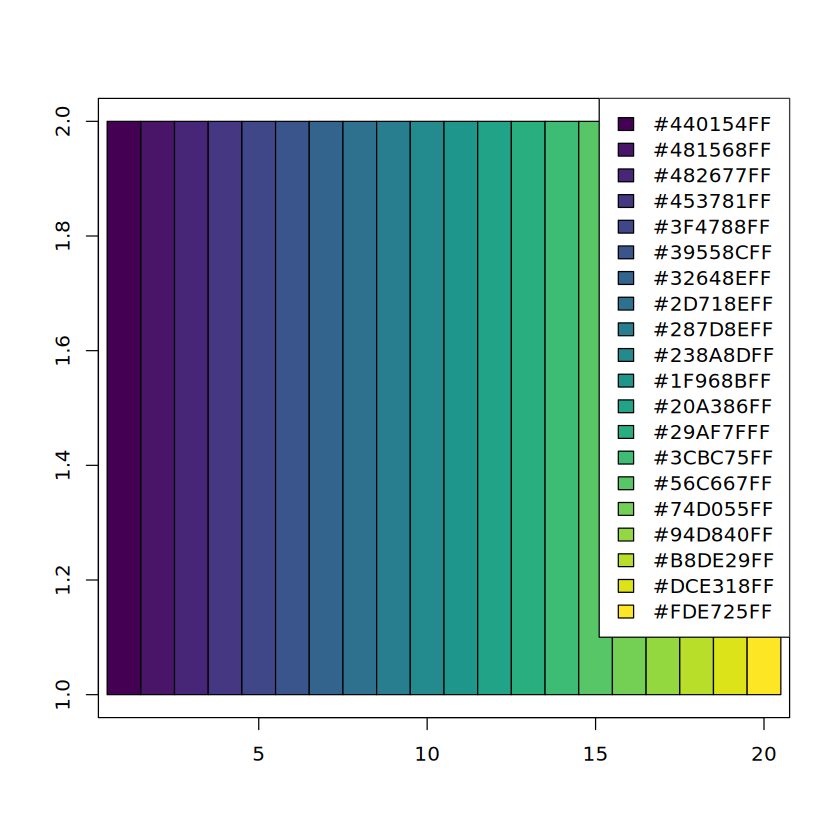

In [1]:
library(ggplot2)
library(RColorBrewer)
library(rgl)
options(rgl.useNULL = TRUE)

source("common.R")
mypal <- viridis::viridis_pal()(20)
plot(1, 1, type = "n", xlim = c(1, length(mypal)), ylim = c(1, 2), xlab = "", ylab = "")
for (i in 1:length(mypal)) {
  rect(i - 0.5, 1, i + 0.5, 2, col = mypal[i])
}
legend("topright", legend = mypal, fill = mypal, bg = "white")

In [2]:
set.seed(12345)

N <- 1000
#g <- barabasi.game(N, m=1, directed=TRUE)
g <- watts.strogatz.game(dim=2, size=20, p=0.05, nei=1)
lay3D <- layout_with_fr(g, dim=3)
lay2D <- layout_with_fr(g, dim=2)

Warning message:
“`watts.strogatz.game()` was deprecated in igraph 2.0.0.
ℹ Please use `sample_smallworld()` instead.”


In [3]:
deg <- degree(g)
centr_deg <- degree(g)
cols_deg <- vec2pal(centr_deg, mypal)
rglplot(g, layout=lay3D, vertex.color=cols_deg, vertex.size=centr_deg, vertex.label=NA, edge.color="gray80", vertex.frame.color=NA, edge.width=0.5)

In [4]:
library(rgl)
options(rgl.useNULL = TRUE)
rgl.quit()
library(rgl)
options(rgl.useNULL = TRUE)

Registered S3 methods overwritten by 'rgl':
  method               from
  knit_print.rglId         
  knit_print.rglOpen3d     
  sew.rglRecordedplot      



In [5]:
# let's calculate some centralities now and we will compare them later at once

# closeness
centr_clos <- closeness(g, normalized=TRUE)
cols_clos <- vec2pal(centr_clos, mypal)

# pagerank
centr_pr <- page_rank(g)$vector
cols_pr <- vec2pal(centr_pr, mypal)

# eigenvector
centr_eig <- eigen_centrality(g)$vector
cols_eig <- vec2pal(centr_eig, mypal)

# hub score
centr_hub <- hub_score(g)$vector
cols_hub <- vec2pal(centr_hub, mypal)

# authority score
centr_auth <- authority_score(g)$vector
cols_auth <- vec2pal(centr_auth, mypal)

centr_pr <- page_rank(g)$vector
centr_eig <- eigen_centrality(g)$vector
centr_hub <- hub_score(g)$vector
centr_auth <- authority_score(g)$vector

Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”
Warning message:
“`authority_score()` was deprecated in igraph 2.1.0.
ℹ Please use `hits_scores()` instead.”


In [6]:
# Create the dataframe
df <- data.frame(
  Degree = centr_deg,
  Betweenness = centr_betw,
  Closeness = centr_clos,
  PageRank = centr_pr,
  Eigenvector = centr_eig,
  Hub = centr_hub,
  Authority = centr_auth
)

# scatter matrix to see the patterns:
pairs(df, pch=19, cex=0.5)

# now let's plot the results on the network and compare:
par(mfrow=c(3, 2), mar=c(2, 2, 1, 1))

plot(g, layout=lay2D, vertex.color=cols_deg, vertex.size=deg, vertex.label=NA, edge.color="gray80", vertex.frame.color=NA, edge.width=0.3, main="Degree")
plot(g, layout=lay2D, vertex.color=cols_betw, vertex.size=deg, vertex.label=NA, edge.color="gray80", vertex.frame.color=NA, edge.width=0.3, main="Betweenness")
plot(g, layout=lay2D, vertex.color=cols_clos, vertex.size=deg, vertex.label=NA, edge.color="gray80", vertex.frame.color=NA, edge.width=0.3, main="Closeness")
plot(g, layout=lay2D, vertex.color=cols_pr, vertex.size=deg, vertex.label=NA, edge.color="gray80", vertex.frame.color=NA, edge.width=0.3, main="PageRank")
plot(g, layout=lay2D, vertex.color=cols_eig, vertex.size=deg, vertex.label=NA, edge.color="gray80", vertex.frame.color=NA, edge.width=0.3, main="Eigenvector")
plot(g, layout=lay2D, vertex.color=cols_hub, vertex.size=deg, vertex.label=NA, edge.color="gray80", vertex.frame.color=NA, edge.width=0.3, main="Hub")


ERROR: Error in as.data.frame.default(x[[i]], optional = TRUE): cannot coerce class ‘"function"’ to a data.frame
